<a href="https://colab.research.google.com/github/marwa189/cervical-cancer-risk-prediction/blob/main/Another_copy_of_cervical_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [349]:
# Cervical Cancer Risk Prediction

## Objective
# This project aims to analyze a cervical cancer dataset and apply machine learning techniques to predict cervical cancer risk.

## Workflow
# 1. Dataset understanding
# 2. Data cleaning
# 3. Exploratory Data Analysis
# 4. Preprocessing
# 5. Model training
# 6. Evaluation

In [350]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [351]:
# read dataset
df=pd.read_csv("risk_factors_cervical_cancer.csv")


In [352]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [353]:
df.shape

(858, 36)

In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [355]:
df.describe()

,Age,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,0.087413,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,0.302545,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [356]:
df.isna().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [357]:
(df == "?").sum()

,0
Age,0
Number of sexual partners,26
First sexual intercourse,7
Num of pregnancies,56
Smokes,13
Smokes (years),13
Smokes (packs/year),13
Hormonal Contraceptives,108
Hormonal Contraceptives (years),108
IUD,117


In [358]:
# hidden missing values
df=df.replace("?",np.nan)

In [359]:
df.isna().sum()

,0
Age,0
Number of sexual partners,26
First sexual intercourse,7
Num of pregnancies,56
Smokes,13
Smokes (years),13
Smokes (packs/year),13
Hormonal Contraceptives,108
Hormonal Contraceptives (years),108
IUD,117


In [360]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           832 non-null    object
 2   First sexual intercourse            851 non-null    object
 3   Num of pregnancies                  802 non-null    object
 4   Smokes                              845 non-null    object
 5   Smokes (years)                      845 non-null    object
 6   Smokes (packs/year)                 845 non-null    object
 7   Hormonal Contraceptives             750 non-null    object
 8   Hormonal Contraceptives (years)     750 non-null    object
 9   IUD                                 741 non-null    object
 10  IUD (years)                         741 non-null    object
 11  STDs                                753 non-null    object

In [361]:
# change to numeric instead of obj caused by ?
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [363]:
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
STDs: Time since first diagnosis,91.724942
STDs: Time since last diagnosis,91.724942
IUD,13.636364
IUD (years),13.636364
Hormonal Contraceptives,12.587413
Hormonal Contraceptives (years),12.587413
STDs:HPV,12.237762
STDs:AIDS,12.237762
STDs:Hepatitis B,12.237762
STDs:HIV,12.237762


In [364]:
df["Biopsy"].value_counts()

,count
Biopsy,
0,803
1,55


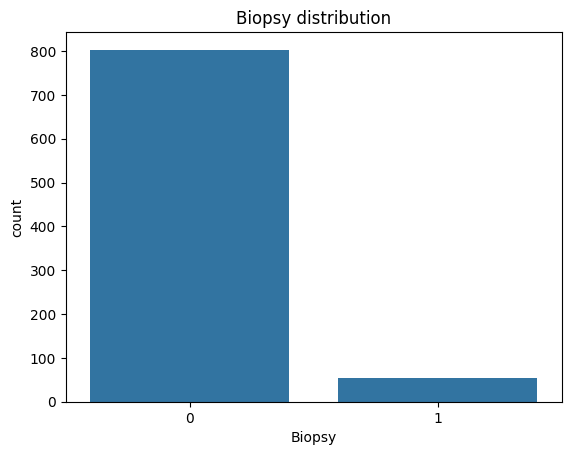

In [365]:
sns.countplot(x="Biopsy",data=df)
plt.title("Biopsy distribution")
plt.show()

In [366]:
! pip install ydata-profiling

In [367]:
# Drop columns with extremely high missing values
df.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis"
], inplace=True)

In [368]:
# zero variance
constant_cols = [
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
]

df.drop(columns=constant_cols, inplace=True)

In [369]:
#duplicate rows
df.duplicated().sum()

np.int64(23)

In [370]:
#delete duplicate rows
df.drop_duplicates(inplace=True)

In [371]:
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
IUD (years),13.413174
IUD,13.413174
Hormonal Contraceptives,12.335329
Hormonal Contraceptives (years),12.335329
STDs,11.976048
STDs:vaginal condylomatosis,11.976048
STDs:condylomatosis,11.976048
STDs (number),11.976048
STDs:vulvo-perineal condylomatosis,11.976048
STDs:HPV,11.976048


In [372]:
#measure skewness
numerical_cols = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Smokes (packs/year)",
    "IUD (years)",
    "Hormonal Contraceptives (years)",
    "STDs (number)"
]

df[numerical_cols].skew()

,0
Age,1.403917
Number of sexual partners,5.481626
First sexual intercourse,1.566655
Num of pregnancies,1.395841
Smokes (years),4.396961
Smokes (packs/year),9.181032
IUD (years),4.934714
Hormonal Contraceptives (years),2.595193
STDs (number),3.352185


In [373]:
# define features and target
X = df.drop("Biopsy", axis=1)
y = df["Biopsy"]

In [374]:
#train test split
# stratify=y: Because dataset is imbalanced
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [375]:
# numerical columns
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

# categorical columns (0/1 features)
categorical_cols = []

for col in numeric_cols:
    unique_vals = set(df[col].dropna().unique())

    if unique_vals.issubset({0, 1}):
        categorical_cols.append(col)

# remove target if present
if "Biopsy" in categorical_cols:
    categorical_cols.remove("Biopsy")

# numerical features only
numeric_cols = [
    col for col in numeric_cols
    if col not in categorical_cols and col != "Biopsy"
]

print("Numerical:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numerical: 10
Categorical: 21


In [376]:
print("Numerical:")
print(numeric_cols)

print("\nCategorical:")
print(categorical_cols)

Numerical:
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis']

Categorical:
['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs', 'STDs:condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology']


In [377]:
# seperate train subsets
X_train_num = X_train[numeric_cols]
X_train_cat = X_train[categorical_cols]
X_test_num = X_test[numeric_cols].copy()
X_test_cat = X_test[categorical_cols].copy()



imputation

In [378]:
# Impute numerical columns with KNN
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

X_train_num = pd.DataFrame(
    knn_imputer.fit_transform(X_train_num),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    knn_imputer.transform(X_test_num),
    columns=numeric_cols,
    index=X_test.index
)

In [379]:
# Impute categorical columns with Most Frequent
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train_cat),
    columns=categorical_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test_cat),
    columns=categorical_cols,
    index=X_test.index
)

In [380]:
# merge them back
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

In [381]:
# restore original column order
X_train = X_train[numeric_cols + categorical_cols]
X_test = X_test[numeric_cols + categorical_cols]

In [382]:
X_train.isna().sum().sum()

np.int64(0)

In [383]:
X_train[categorical_cols].head()

,Smokes,Hormonal Contraceptives,IUD,STDs,STDs:condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,...,STDs:HIV,STDs:Hepatitis B,STDs:HPV,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology
557,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
386,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
121,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [384]:
X_train[categorical_cols].tail()

,Smokes,Hormonal Contraceptives,IUD,STDs,STDs:condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,...,STDs:HIV,STDs:Hepatitis B,STDs:HPV,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology
568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
375,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
556,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
581,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [385]:
# count nas now
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0


feature selection

In [386]:
cols_to_drop = [
    "Hinselmann",
    "Schiller",
    "Citology"
]

In [387]:
print(X_train.shape)
print(X_test.shape)

(668, 31)
(167, 31)


In [388]:
[col for col in cols_to_drop if col in X_train.columns]

['Hinselmann', 'Schiller', 'Citology']

# Baseline Models

After completing preprocessing and exploratory data analysis, baseline machine learning models will be trained to establish initial performance benchmarks.

The project begins with:
- Logistic Regression
- Random Forest

These models provide a comparison between interpretable linear modeling and robust tree-based learning approaches.

In [389]:
# Scale features for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [390]:
# train logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [391]:
# predict on test values
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]



In [392]:
#import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [393]:
# confusion matrix
confusion_matrix(y_test, y_pred_lr)

array([[152,   4],
       [  2,   9]])

In [394]:
# print matrix
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.9640718562874252
Precision: 0.6923076923076923
Recall: 0.8181818181818182
F1-score: 0.75
ROC-AUC: 0.9399766899766899


In [395]:
# predict on train values
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_prob_lr_train = lr_model.predict_proba(X_train_scaled)[:, 1]

In [396]:
# print matrix for train prediction
print("Accuracy:", accuracy_score(y_train, y_pred_lr_train))
print("Precision:", precision_score(y_train, y_pred_lr_train))
print("Recall:", recall_score(y_train, y_pred_lr_train))
print("F1-score:", f1_score(y_train, y_pred_lr_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_lr_train))

Accuracy: 0.9520958083832335
Precision: 0.5797101449275363
Recall: 0.9302325581395349
F1-score: 0.7142857142857143
ROC-AUC: 0.9811348837209303




The F1-score of approximately 0.69 reflects the balance between recall and precision, providing a more reliable evaluation metric for this imbalanced healthcare dataset than accuracy alone.

In [397]:
# import random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [398]:
#predict on test
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [399]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9520958083832335
Precision: 0.7142857142857143
Recall: 0.45454545454545453
F1-score: 0.5555555555555556
ROC-AUC: 0.9647435897435898


In [400]:
# confusion matric
confusion_matrix(y_test, y_pred_rf)

array([[154,   2],
       [  6,   5]])

In [401]:
# predict on train
y_pred_rf_train = rf_model.predict(X_train)
y_prob_rf_train = rf_model.predict_proba(X_train)[:, 1]

In [402]:
# print matrices for train prediction
print("Accuracy:", accuracy_score(y_train, y_pred_rf_train))
print("Precision:", precision_score(y_train, y_pred_rf_train))
print("Recall:", recall_score(y_train, y_pred_rf_train))
print("F1-score:", f1_score(y_train, y_pred_rf_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_rf_train))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
ROC-AUC: 1.0


The Random Forest baseline model achieved high overall accuracy and strong precision, producing fewer false positive predictions compared to Logistic Regression.

However, the model showed significantly lower recall, indicating that several actual positive biopsy cases were missed.

Although Random Forest was more conservative and precise in positive predictions, Logistic Regression demonstrated better sensitivity toward detecting positive biopsy outcomes, which is particularly important in healthcare-related classification tasks.

## Gradient Boosting Baseline Model

Gradient Boosting is added as a more advanced ensemble model. Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees sequentially, where each new tree tries to correct the errors of the previous ones.

This model is evaluated first without SMOTE or hyperparameter tuning to understand its baseline behavior on the preprocessed dataset.

In [403]:
# import gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

In [404]:
# create the model
gb_model = GradientBoostingClassifier(
    random_state=42
)

# train the model
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [405]:
# predict
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [406]:
# print evaluation matrices
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1-score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
#

Accuracy: 0.9700598802395209
Precision: 0.75
Recall: 0.8181818181818182
F1-score: 0.782608695652174
ROC-AUC: 0.921037296037296


In [407]:
# confusion matrix
confusion_matrix(y_test, y_pred_gb)

array([[153,   3],
       [  2,   9]])

In [409]:
mi_df.head(15)

,Feature,Mutual Information
29,Schiller,0.127793
28,Hinselmann,0.062080
11,Hormonal Contraceptives,0.021441
17,STDs:syphilis,0.020291
0,Age,0.018932
23,STDs:HPV,0.017997
15,STDs:vaginal condylomatosis,0.016897
24,Dx:Cancer,0.015323
7,IUD (years),0.014549
26,Dx:HPV,0.012680


SMOTE was added as an extra experiment because the dataset is highly imbalanced and positive biopsy cases are clinically important. Its effect was evaluated by comparing model performance before and after balancing, especially recall, false negatives, precision, and F1-score.

In [410]:
# import smote
from imblearn.over_sampling import SMOTE

In [411]:
# create smote object
smote = SMOTE(random_state=42)

In [412]:
# apply smote only on training data
# for logistic regression
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [413]:
# verify new balance
y_train_smote.value_counts()
#

,count
Biopsy,
0,625
1,625


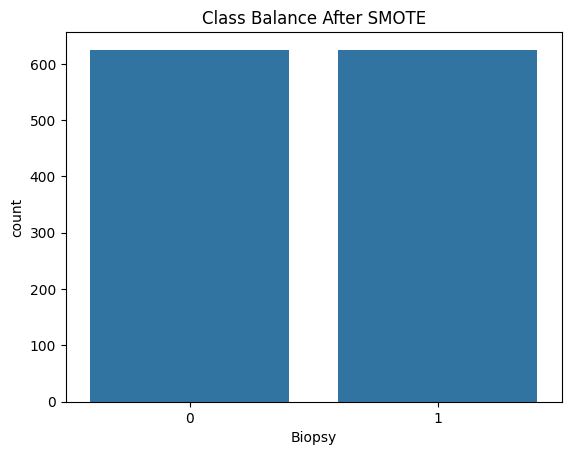

In [414]:
#visualize class balance
sns.countplot(x=y_train_smote)
plt.title("Class Balance After SMOTE")
plt.show()
#

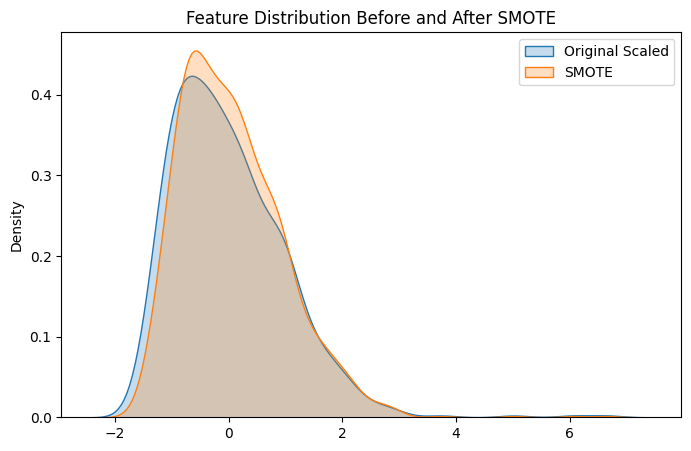

In [415]:
plt.figure(figsize=(8,5))

sns.kdeplot(X_train_scaled[:,0], label="Original Scaled", fill=True)
sns.kdeplot(X_train_smote[:,0], label="SMOTE", fill=True)

plt.legend()
plt.title("Feature Distribution Before and After SMOTE")
plt.show()

In [416]:
#train with X_train_smote and y_train_smote
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [417]:
# pridect
# Use ORIGINAL untouched test set
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_prob_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]
#

In [418]:
# print evaluayion matrices
print("Accuracy:", accuracy_score(y_test, y_pred_lr_smote))
print("Precision:", precision_score(y_test, y_pred_lr_smote))
print("Recall:", recall_score(y_test, y_pred_lr_smote))
print("F1-score:", f1_score(y_test, y_pred_lr_smote))

Accuracy: 0.9700598802395209
Precision: 0.75
Recall: 0.8181818181818182
F1-score: 0.782608695652174


In [419]:
#compare with results before smote
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.9640718562874252
Precision: 0.6923076923076923
Recall: 0.8181818181818182
F1-score: 0.75


In [420]:
# check confusion matrix before and after smote
print("Without SMOTE")
print(confusion_matrix(y_test, y_pred_lr))

print("\nWith SMOTE")
print(confusion_matrix(y_test, y_pred_lr_smote))

Without SMOTE
[[152   4]
 [  2   9]]

With SMOTE
[[153   3]
 [  2   9]]


In [421]:
print(y_pred_lr[:10])
print(y_pred_lr_smote[:10])

[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


In [422]:
# crete smote to inscaled train data for gradient boost

smote_gr = SMOTE(random_state=42)

X_train_smote_gb, y_train_smote_gb = smote_gr.fit_resample(X_train, y_train)

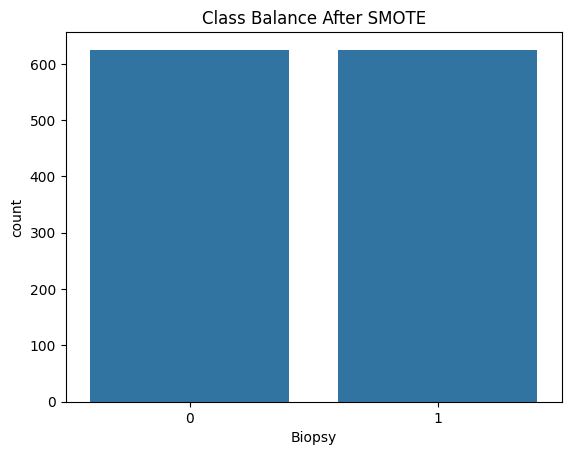

In [423]:
# visualize class balance
sns.countplot(x=y_train_smote_gb)
plt.title("Class Balance After SMOTE")
plt.show()

In [424]:
# create a gradient booster model with SMOTE
gb_smote = GradientBoostingClassifier(random_state=42)

gb_smote.fit(X_train_smote_gb, y_train_smote_gb)

GradientBoostingClassifier(random_state=42)

In [425]:
y_pred_gb_smote = gb_smote.predict(X_test)
y_prob_gb_smote = gb_smote.predict_proba(X_test)[:, 1]

In [426]:
# print matrices
print("Accuracy:", accuracy_score(y_test, y_pred_gb_smote))
print("Precision:", precision_score(y_test, y_pred_gb_smote))
print("Recall:", recall_score(y_test, y_pred_gb_smote))
print("F1-score:", f1_score(y_test, y_pred_gb_smote))


Accuracy: 0.9820359281437125
Precision: 0.8333333333333334
Recall: 0.9090909090909091
F1-score: 0.8695652173913043


In [428]:
# confusion matrix
confusion_matrix(y_test, y_pred_gb_smote)

array([[154,   2],
       [  1,  10]])

## Overfitting Check

Training and testing F1-scores are compared to investigate potential overfitting after applying SMOTE and Gradient Boosting.

In [429]:
# Predict on Training Set
y_train_pred_gb_smote = gb_smote.predict(X_train)

In [430]:
# compute train F1
train_f1_gb_smote = f1_score(y_train, y_train_pred_gb_smote)
print("Training F1-score (Gradient Boosting with SMOTE):", train_f1_gb_smote)


Training F1-score (Gradient Boosting with SMOTE): 0.9655172413793104


In [431]:
y_train_pred_lr = lr_model.predict(X_train_scaled)
train_f1_lr = f1_score(y_train, y_train_pred_lr)

y_train_pred_lr_smote = lr_smote.predict(X_train_smote)
train_f1_lr_smote = f1_score(y_train_smote, y_train_pred_lr_smote)

y_train_pred_gb = gb_model.predict(X_train)
train_f1_gb = f1_score(y_train, y_train_pred_gb)

In [432]:
# comparison table
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE",
        "Gradient Boosting",
        "Gradient Boosting + SMOTE"
    ],
    "Train F1": [
        train_f1_lr,
        train_f1_lr_smote,
        train_f1_gb,
        train_f1_gb_smote
    ],
    "Test F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr_smote),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_gb_smote)
    ]
})

comparison_df["Gap"] = comparison_df["Train F1"] - comparison_df["Test F1"]

comparison_df

,Model,Train F1,Test F1,Gap
0,Logistic Regression,0.714286,0.750000,-0.035714
1,Logistic Regression + SMOTE,0.960064,0.782609,0.177455
2,Gradient Boosting,0.988235,0.782609,0.205627
3,Gradient Boosting + SMOTE,0.965517,0.869565,0.095952


Gradient Boosting with SMOTE achieved the highest test F1-score (0.91) while maintaining a relatively small train-test gap (0.06), indicating strong generalization and limited overfitting. Compared to the other models, it provided the best balance between predictive performance and robustness on unseen data, making it the most promising candidate for further optimization.

## Hyperparameter Tuning

Gradient Boosting with SMOTE was selected as the best-performing model. Hyperparameter tuning is performed using GridSearchCV to optimize the F1-score, providing a balance between recall and precision while reducing the risk of false negatives.

In [433]:
# imports
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier



In [434]:
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))
])

In [452]:
# parameter grid
param_grid =  {
    "gb__n_estimators": [50, 100, 200],
    "gb__learning_rate": [0.01, 0.05, 0.1],
    "gb__max_depth": [2, 3, 4]

}

In [453]:
grid_search=GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [454]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('gb',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'gb__learning_rate': [0.01, 0.05, 0.1],
                         'gb__max_depth': [2, 3, 4],
                         'gb__n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

In [455]:
# best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'gb__learning_rate': 0.05, 'gb__max_depth': 2, 'gb__n_estimators': 50}


In [456]:
# best score
best_score = grid_search.best_score_
print("Best Score (F1):", best_score)

Best Score (F1): 0.7146252440370088


In [457]:
# best model
best_model = grid_search.best_estimator_
print("Best Model:", best_model)

Best Model: Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('gb',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
                                            n_estimators=50,
                                            random_state=42))])


In [458]:
y_pred_best = grid_search.predict(X_test)

print("F1:", f1_score(y_test, y_pred_best))

F1: 0.8333333333333334


In [459]:
param_grid

{'gb__n_estimators': [50, 100, 200],
 'gb__learning_rate': [0.01, 0.05, 0.1],
 'gb__max_depth': [2, 3, 4]}

PCA